<a href="https://colab.research.google.com/github/Sanskruti236/ML-Practical/blob/main/Practical_No_10_Roll_No_519.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self,output_gradient, learning_rate):
        pass

In [ ]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, input_gradient):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        return input_gradient

In [ ]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

In [ ]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [ ]:
class Tanh(Activation):
    def __init__(self):
        def tanh(x):
            return np.tanh(x)

        def tanh_prime(x):
            return 1- np.tanh(x) ** 2

        super().__init__(tanh, tanh_prime)


class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))

        def sigmoid_prime(x):
            s = sigmoid(x)
            return s * (1-s)

        super().__init__(sigmoid, sigmoid_prime)

In [ ]:
import math

In [ ]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x

        def linear_prime(x):
            return 1

        super().__init__(linear, linear_prime)

4A

In [ ]:
X = np.linspace(-3,3,61)
Y = [math.sin(p) for p in X]

network = [
    Dense(1, 10),
    Tanh(),
    Dense(10, 1),
    Linear()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(X,Y):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(X)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=4.405235979895668
2/(50, error=0.5824919471555281
3/(50, error=0.006136994847972894
4/(50, error=0.07387562114470286
5/(50, error=0.005763451832643814
6/(50, error=0.021977028763567084
7/(50, error=0.006797648565556272
8/(50, error=0.006564010292767479
9/(50, error=0.004067547413940529
10/(50, error=0.0035752673226676335
11/(50, error=0.003319839967813367
12/(50, error=0.003583507322613514
13/(50, error=0.004159083677117396
14/(50, error=0.005060999955997913
15/(50, error=0.006196632540503037
16/(50, error=0.007458749447976928
17/(50, error=0.008705748494553878
18/(50, error=0.009827057310594033
19/(50, error=0.010762937458929317
20/(50, error=0.011509622662260285
21/(50, error=0.012096080176077894
22/(50, error=0.012559148578590347
23/(50, error=0.01292503159084712
24/(50, error=0.013204981721437125
25/(50, error=0.013400502056567207
26/(50, error=0.01351118656583278
27/(50, error=0.013539763972440716
28/(50, error=0.013493415101923036
29/(50, error=0.013382680223482145
3

In [ ]:
actual_Y = []
for x in X:
    output = x
    for layer in network:
        output=layer.forward(output)
    actual_Y.append(output[0])
    print(output)

[[-0.69436855]]
[[-0.71758071]]
[[-0.74134492]]
[[-0.76531009]]
[[-0.78908242]]
[[-0.81223965]]
[[-0.83434594]]
[[-0.85496489]]
[[-0.87366859]]
[[-0.89004141]]
[[-0.90367818]]
[[-0.9141779]]
[[-0.92113508]]
[[-0.92413166]]
[[-0.92273282]]
[[-0.9164892]]
[[-0.90494624]]
[[-0.8876578]]
[[-0.86419605]]
[[-0.83414579]]
[[-0.79707173]]
[[-0.75245998]]
[[-0.69966268]]
[[-0.63791425]]
[[-0.5665133]]
[[-0.48522771]]
[[-0.39483195]]
[[-0.29746505]]
[[-0.1964129]]
[[-0.09521096]]
[[0.00349612]]
[[0.09865867]]
[[0.1907498]]
[[0.28110746]]
[[0.37110913]]
[[0.46149474]]
[[0.55196791]]
[[0.64109471]]
[[0.72647804]]
[[0.80515835]]
[[0.87415047]]
[[0.93098424]]
[[0.97410558]]
[[1.00303638]]
[[1.01827517]]
[[1.02100723]]
[[1.01274151]]
[[0.99498604]]
[[0.96902782]]
[[0.93582983]]
[[0.8960207]]
[[0.8499398]]
[[0.79770519]]
[[0.73928367]]
[[0.67455351]]
[[0.60335807]]
[[0.52555248]]
[[0.44104605]]
[[0.34984304]]
[[0.25208213]]
[[0.14807332]]


In [ ]:
import matplotlib.pyplot as plt

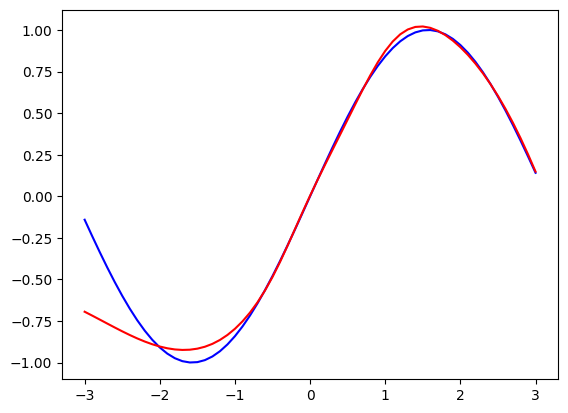

In [ ]:
plt.plot(X,Y,color='blue')
plt.plot(X, actual_Y,color='red')
plt.show()

4B

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
def preprocess_data(x, y, limit):
        x = x.reshape(x.shape[0], 28 * 28, 1)
        x = x.astype("float32")/255

        y = to_categorical(y)
        y = y.reshape(y.shape[0], 10, 1)

        return x[:limit], y[:limit]

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, y_train = preprocess_data(x_train, y_train, 10000)
x_test, y_test = preprocess_data(x_test, y_test, 20)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(x_train,y_train):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(x)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=1.2128830168184492
2/(50, error=1.004586792728454
3/(50, error=0.9437401072747013
4/(50, error=0.9066793476730883
5/(50, error=0.8805989829785593
6/(50, error=0.8479974025325131
7/(50, error=0.7935192735391834
8/(50, error=0.7525648657045445
9/(50, error=0.7125808201335853
10/(50, error=0.6792535266428852
11/(50, error=0.6516900085150779
12/(50, error=0.6220493422896269
13/(50, error=0.579182911793925
14/(50, error=0.5435620222793685
15/(50, error=0.5187737683769496
16/(50, error=0.5017078671224345
17/(50, error=0.487373960480888
18/(50, error=0.47174973429271766
19/(50, error=0.4500961607411009
20/(50, error=0.42024953036855756
21/(50, error=0.3948392103941394
22/(50, error=0.3758919109922255
23/(50, error=0.3620569591869748
24/(50, error=0.35161948339413973
25/(50, error=0.34299626323189214
26/(50, error=0.33544001035512916
27/(50, error=0.32866291109630336
28/(50, error=0.3225185540870251
29/(50, error=0.31691005403352934
30/(50, error=0.31176667614157777
31/(50, error=

In [ ]:
def predict(network, input):
    output = input
    for layer in network:
        output = layer.forward(output)
    return output

In [ ]:
#!pip install simple-colors

In [ ]:
import sys
!{sys.executable} -m pip install simple-colors
import simple_colors

In [ ]:
correct = 0

for x,y in zip(x_test, y_test):
    output = predict(network ,x)
    if np.argmax(output) == np.argmax(y):
        correct += 1
        print('pred:', np.argmax(output), '\ttrue:', np.argmax(y))
    else:
        print(simple_colors.red(f'pred: {np.argmax(output)} \ttrue: {np.argmax(y)}'))

accuracy = correct / len(y_test)
print(f"Accuracy: {accuracy}")
print(f"Correct: {correct}")

pred: 7 	true: 7
pred: 2 	true: 2
pred: 1 	true: 1
pred: 9 	true: 0
pred: 4 	true: 4
pred: 1 	true: 1
pred: 4 	true: 4
pred: 9 	true: 9
pred: 2 	true: 5
pred: 9 	true: 9
pred: 3 	true: 0
pred: 6 	true: 6
pred: 9 	true: 9
pred: 9 	true: 0
pred: 1 	true: 1
pred: 5 	true: 5
pred: 9 	true: 9
pred: 7 	true: 7
pred: 3 	true: 3
pred: 4 	true: 4
Accuracy: 0.8
Correct: 16


In [ ]:
error = errorlist
X = list(range(1,len(errorlist) + 1))

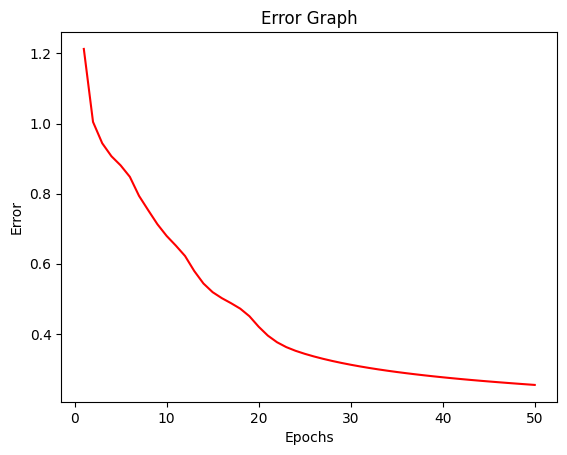

In [ ]:
plt.plot(X, error, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()